In [2]:
import matplotlib.pyplot as plt
import distinctipy
import numpy as np 
import pandas as pd 
import os 
import pickle
import matplotlib
import sys
from pathlib import Path
REPO_ROOT = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(REPO_ROOT / "code"))
from plot_of_experiment_data import *
from make_network import sez
matplotlib.rcParams['svg.fonttype'] = 'none'
matplotlib.rcParams['font.family'] = 'Arial'

In [3]:
labial_hits = ['control','SS48949', 'SS48944', 'SS47082', 'SS47080', 'SS56399', 'SS46885',
       'SS46889', 'SS31321', 'SS31320', 'SS48947', 'SS48948', 'SS15725',
        'SS46917', 'SS50091', 'SS47730', 'SS47731', 'SS47744',
       'SS47745', 'SS37122']

tarsal_hits = ['control','SS48944', 'SS48949', 'SS48948', 'SS47730','SS47731', 'SS47744', 'SS35412', 'SS35420']



In [4]:
import pandas as pd

def read_screening_data(fpath,hits):
    # 모든 sheet 읽기
    sheets = pd.ExcelFile(fpath).sheet_names

    data_df = {}
    for s in sheets:
        df = pd.read_excel(fpath, sheet_name=s)
        col_to_hit = {col: col.split(' ')[0] for col in df.columns}
        ordered_cols = [
            col
            for hit in hits
            for col, h in col_to_hit.items()
            if h == hit
        ]

        data_df[s] = df[ordered_cols]

    # mean / SEM
    conds = ['sugar', 'sugar+geosmin']

    mean_df = pd.DataFrame(
        index=data_df['sugar'].columns,
        columns=conds
    )

    std_df = pd.DataFrame(
        index=data_df['sugar'].columns,
        columns=conds
    )

    for cond in conds:
        mean_df[cond] = data_df[cond].mean()
        std_df[cond] = std_err(data_df[cond])

    return data_df, mean_df, std_df

# Labial
data_df_labial, mean_df_labial, std_df_labial = read_screening_data(
    'data/labial_screening.xlsx',labial_hits
)

# Tarsal
data_df_tarsal, mean_df_tarsal, std_df_tarsal = read_screening_data(
    'data/tarsal_screening.xlsx',tarsal_hits
)

(-0.2, 5.9)

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

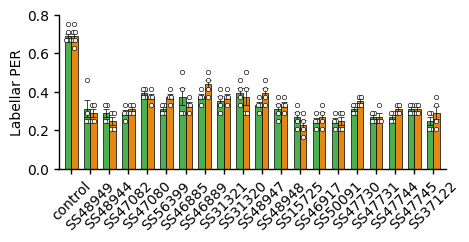

In [5]:
fig,ax = plt.subplots(1,1,figsize=(5,2)) # ,figsize=(1.2,1)

ax = draw_paired_bar_figure(
    data=data_df_labial,
    mean_df=mean_df_labial,
    err_df=std_df_labial,
    bar_width = 0.1,
    bar_spacing=.3,
    stat_fontsize = 10,
    fontsize=10,
    dot_size=10,
    capsize=2,
    ax=ax,
    conds=mean_df_labial.index,
    groups=mean_df_labial.columns,
    get_values=lambda data, cond, group: data[group][cond],
    stat_pairs=None,
    colors=('#4CAF50','#E68613'),
    ylabel='Labellar PER',
    xtick_func=lambda c: c.split(' ')[0],
    ylim=(0, 0.8),
    yticks=np.round(np.arange(0, .81, .2), 2)
)
ax.tick_params('x',rotation=45)
ax.tick_params(
    axis='both',
    width=1,      # tick line 두께
)
for spine in ax.spines.values():
    spine.set_linewidth(1)
ax.set_xlim([-.2,5.9])
# plt.savefig('Labeller_screening_hits.svg',bbox_inches='tight')

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

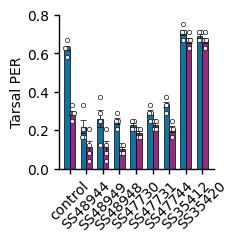

In [40]:
fig,ax = plt.subplots(1,1,figsize=(2,2)) # ,figsize=(1.2,1)

ax = draw_paired_bar_figure(
    data=data_df_tarsal,
    mean_df=mean_df_tarsal,
    err_df=std_df_tarsal,
    bar_width = 0.1,
    bar_spacing=.3,
    stat_fontsize = 10,
    fontsize=10,
    dot_size=10,
    capsize=2,
    ax=ax,
    conds=mean_df_tarsal.index,
    groups=mean_df_tarsal.columns,
    get_values=lambda data, cond, group: data[group][cond],
    stat_pairs=None,
    colors=('#13739E','#952B7E'),
    ylabel='Tarsal PER',
    xtick_func=lambda c: c.split(' ')[0],
    ylim=(0, 0.8),
    
    yticks=np.round(np.arange(0, .81, .2), 2)
)
ax.tick_params('x',rotation=45)
ax.tick_params(
    axis='both',
    width=1,      # tick line 두께
)
for spine in ax.spines.values():
    spine.set_linewidth(1)
ax.set_xlim([-.2,2.6])
plt.savefig('Tarsal_screening_hits.svg',bbox_inches='tight')